In [1]:
# Persiapan eksperimen Focal Loss

from pathlib import Path
import random
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights


# Konfigurasi yang disamakan dengan baseline BCE
SEED = 42
BATCH_SIZE = 16
NUM_WORKERS = 2
IMAGE_SIZE = 224
FOCAL_ALPHA = 0.25
FOCAL_GAMMA = 2.0

LABELS = ["N", "D", "G", "C", "A", "H", "M", "O"]

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


# Menetapkan seed agar eksperimen dapat diulang
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# Lokasi dataset Kaggle
DATASET_DIR = Path(
    "/kaggle/input/datasets/kevinardhana/"
    "odir-5k-patient-level-multi-label-fundus-dataset"
)

IMAGE_DIR = (
    DATASET_DIR
    / "Training Images"
    / "Training Images"
)

TRAIN_CSV = DATASET_DIR / "train.csv"
VALID_CSV = DATASET_DIR / "validation.csv"
TEST_CSV = DATASET_DIR / "test.csv"

FOCAL_OUTPUT_DIR = Path(
    "/kaggle/working/focal_loss"
)
FOCAL_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# Memuat pembagian data
focal_train_df = pd.read_csv(TRAIN_CSV)
focal_valid_df = pd.read_csv(VALID_CSV)
focal_test_df = pd.read_csv(TEST_CSV)


# Memeriksa ukuran dan pemisahan pasien
assert len(focal_train_df) == 2450
assert len(focal_valid_df) == 525
assert len(focal_test_df) == 525

assert set(focal_train_df["patient_id"]).isdisjoint(
    focal_valid_df["patient_id"]
)

assert set(focal_train_df["patient_id"]).isdisjoint(
    focal_test_df["patient_id"]
)

assert set(focal_valid_df["patient_id"]).isdisjoint(
    focal_test_df["patient_id"]
)


# Ringkasan distribusi label hanya dari data training
positive_counts = focal_train_df[LABELS].sum()
negative_counts = len(focal_train_df) - positive_counts

class_distribution_table = pd.DataFrame({
    "label": LABELS,
    "positif_train": positive_counts.values.astype(int),
    "negatif_train": negative_counts.values.astype(int)
})


# Transformasi citra
focal_train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1,
        hue=0.02
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

focal_eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# Dataset pasangan mata kiri dan kanan
class FocalFundusPairDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        left_path = self.image_dir / row["left_image"]
        right_path = self.image_dir / row["right_image"]

        left_image = Image.open(left_path).convert("RGB")
        right_image = Image.open(right_path).convert("RGB")

        left_image = self.transform(left_image)
        right_image = self.transform(right_image)

        labels = torch.tensor(
            row[LABELS].values.astype(np.float32),
            dtype=torch.float32
        )

        return {
            "left_image": left_image,
            "right_image": right_image,
            "labels": labels,
            "patient_id": int(row["patient_id"])
        }


focal_train_dataset = FocalFundusPairDataset(
    focal_train_df,
    IMAGE_DIR,
    focal_train_transform
)

focal_valid_dataset = FocalFundusPairDataset(
    focal_valid_df,
    IMAGE_DIR,
    focal_eval_transform
)

focal_test_dataset = FocalFundusPairDataset(
    focal_test_df,
    IMAGE_DIR,
    focal_eval_transform
)


focal_train_loader = DataLoader(
    focal_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=DEVICE.type == "cuda"
)

focal_valid_loader = DataLoader(
    focal_valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=DEVICE.type == "cuda"
)

focal_test_loader = DataLoader(
    focal_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=DEVICE.type == "cuda"
)


# Arsitektur yang sama dengan baseline BCE
class FocalSharedResNet50(nn.Module):
    def __init__(self, num_labels=8, dropout=0.30):
        super().__init__()

        self.backbone = resnet50(
            weights=ResNet50_Weights.IMAGENET1K_V2
        )

        feature_dim = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(feature_dim * 2, num_labels)
        )

    def forward(self, left_image, right_image):
        left_features = self.backbone(left_image)
        right_features = self.backbone(right_image)

        combined_features = torch.cat(
            [left_features, right_features],
            dim=1
        )

        return self.classifier(combined_features)


focal_model = FocalSharedResNet50(
    num_labels=len(LABELS)
).to(DEVICE)


# Perbedaan utama dari BCE standar
class SigmoidFocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        if not 0.0 <= alpha <= 1.0:
            raise ValueError("alpha harus berada pada rentang 0 sampai 1.")
        if gamma < 0.0:
            raise ValueError("gamma tidak boleh negatif.")
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce_loss = F.binary_cross_entropy_with_logits(
            logits,
            targets,
            reduction="none"
        )
        probabilities = torch.sigmoid(logits)
        p_t = (
            probabilities * targets
            + (1.0 - probabilities) * (1.0 - targets)
        )
        alpha_t = (
            self.alpha * targets
            + (1.0 - self.alpha) * (1.0 - targets)
        )
        focal_factor = (1.0 - p_t).pow(self.gamma)
        return (alpha_t * focal_factor * bce_loss).mean()


focal_criterion = SigmoidFocalLoss(
    alpha=FOCAL_ALPHA,
    gamma=FOCAL_GAMMA
)


# Pemeriksaan satu batch
focal_batch = next(iter(focal_train_loader))

left_batch = focal_batch["left_image"].to(DEVICE)
right_batch = focal_batch["right_image"].to(DEVICE)
label_batch = focal_batch["labels"].to(DEVICE)

with torch.no_grad():
    focal_logits = focal_model(
        left_batch,
        right_batch
    )


print("Persiapan Focal Loss berhasil.")
print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("\nJumlah data:")
print("Train      :", len(focal_train_dataset))
print("Validation :", len(focal_valid_dataset))
print("Test       :", len(focal_test_dataset))

print("\nBentuk input:")
print("Citra kiri :", left_batch.shape)
print("Citra kanan:", right_batch.shape)
print("Label      :", label_batch.shape)
print("Logits     :", focal_logits.shape)

print("\nParameter Focal Loss:")
print("Alpha:", FOCAL_ALPHA)
print("Gamma:", FOCAL_GAMMA)

print("\nDistribusi label data training:")
display(class_distribution_table)


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 219MB/s]


Persiapan Focal Loss berhasil.
Device: cuda
GPU: Tesla T4

Jumlah data:
Train      : 2450
Validation : 525
Test       : 525

Bentuk input:
Citra kiri : torch.Size([16, 3, 224, 224])
Citra kanan: torch.Size([16, 3, 224, 224])
Label      : torch.Size([16, 8])
Logits     : torch.Size([16, 8])

Parameter Focal Loss:
Alpha: 0.25
Gamma: 2.0

Distribusi label data training:


,label,positif_train,negatif_train
0,N,796,1654
1,D,790,1660
2,G,151,2299
3,C,148,2302
4,A,115,2335
5,H,72,2378
6,M,122,2328
7,O,685,1765


In [2]:
# Training Focal Loss

import json
from sklearn.metrics import f1_score
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau


LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 30
EARLY_STOPPING_PATIENCE = 7


focal_optimizer = AdamW(
    focal_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

focal_scheduler = ReduceLROnPlateau(
    focal_optimizer,
    mode="max",
    factor=0.5,
    patience=2
)


def train_focal_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):
    model.train()

    total_loss = 0.0
    total_samples = 0

    for batch in loader:
        left_images = batch["left_image"].to(
            device,
            non_blocking=True
        )
        right_images = batch["right_image"].to(
            device,
            non_blocking=True
        )
        labels = batch["labels"].to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad()

        logits = model(left_images, right_images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size

    return total_loss / total_samples


@torch.no_grad()
def evaluate_weighted(
    model,
    loader,
    criterion,
    device,
    threshold=0.5
):
    model.eval()

    total_loss = 0.0
    total_samples = 0

    all_labels = []
    all_probabilities = []

    for batch in loader:
        left_images = batch["left_image"].to(
            device,
            non_blocking=True
        )
        right_images = batch["right_image"].to(
            device,
            non_blocking=True
        )
        labels = batch["labels"].to(
            device,
            non_blocking=True
        )

        logits = model(left_images, right_images)
        loss = criterion(logits, labels)

        probabilities = torch.sigmoid(logits)

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size

        all_labels.append(labels.cpu().numpy())
        all_probabilities.append(
            probabilities.cpu().numpy()
        )

    true_labels = np.concatenate(
        all_labels,
        axis=0
    )

    probabilities = np.concatenate(
        all_probabilities,
        axis=0
    )

    predictions = (
        probabilities >= threshold
    ).astype(np.int32)

    macro_f1 = f1_score(
        true_labels,
        predictions,
        average="macro",
        zero_division=0
    )

    micro_f1 = f1_score(
        true_labels,
        predictions,
        average="micro",
        zero_division=0
    )

    return {
        "loss": total_loss / total_samples,
        "macro_f1": float(macro_f1),
        "micro_f1": float(micro_f1)
    }


focal_history = []
focal_best_macro_f1 = -1.0
focal_best_epoch = 0
focal_patience_counter = 0

focal_checkpoint_path = (
    FOCAL_OUTPUT_DIR
    / "best_focal_loss_resnet50.pt"
)

focal_history_path = (
    FOCAL_OUTPUT_DIR
    / "training_history.json"
)


for epoch in range(1, MAX_EPOCHS + 1):
    train_loss = train_focal_one_epoch(
        model=focal_model,
        loader=focal_train_loader,
        criterion=focal_criterion,
        optimizer=focal_optimizer,
        device=DEVICE
    )

    validation_result = evaluate_weighted(
        model=focal_model,
        loader=focal_valid_loader,
        criterion=focal_criterion,
        device=DEVICE,
        threshold=0.5
    )

    validation_loss = validation_result["loss"]
    validation_macro_f1 = validation_result["macro_f1"]
    validation_micro_f1 = validation_result["micro_f1"]

    focal_scheduler.step(
        validation_macro_f1
    )

    current_lr = focal_optimizer.param_groups[0]["lr"]

    epoch_result = {
        "epoch": epoch,
        "train_loss": float(train_loss),
        "validation_loss": float(validation_loss),
        "validation_macro_f1": validation_macro_f1,
        "validation_micro_f1": validation_micro_f1,
        "learning_rate": float(current_lr)
    }

    focal_history.append(epoch_result)

    print(
        f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
        f"train loss: {train_loss:.4f} | "
        f"val loss: {validation_loss:.4f} | "
        f"val Macro-F1: {validation_macro_f1:.4f} | "
        f"val Micro-F1: {validation_micro_f1:.4f} | "
        f"lr: {current_lr:.6f}"
    )

    if validation_macro_f1 > focal_best_macro_f1:
        focal_best_macro_f1 = validation_macro_f1
        focal_best_epoch = epoch
        focal_patience_counter = 0

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict":
                    focal_model.state_dict(),
                "optimizer_state_dict":
                    focal_optimizer.state_dict(),
                "best_macro_f1":
                    focal_best_macro_f1,
                "labels": LABELS,
                "focal_alpha": FOCAL_ALPHA,
                "focal_gamma": FOCAL_GAMMA,
                "image_size": IMAGE_SIZE,
                "dropout": 0.30,
                "learning_rate": LEARNING_RATE,
                "weight_decay": WEIGHT_DECAY,
                "seed": SEED
            },
            focal_checkpoint_path
        )

        print("  Checkpoint terbaik disimpan.")

    else:
        focal_patience_counter += 1

    with open(focal_history_path, "w") as file:
        json.dump(
            focal_history,
            file,
            indent=2
        )

    if (
        focal_patience_counter
        >= EARLY_STOPPING_PATIENCE
    ):
        print(
            f"Early stopping pada epoch {epoch}. "
            f"Checkpoint terbaik: epoch "
            f"{focal_best_epoch}."
        )
        break


print("\nTraining Focal Loss selesai.")
print("Best epoch:", focal_best_epoch)
print(
    "Best validation Macro-F1:",
    f"{focal_best_macro_f1:.4f}"
)
print("Checkpoint:", focal_checkpoint_path)
print("History:", focal_history_path)

Epoch 01/30 | train loss: 0.0359 | val loss: 0.0310 | val Macro-F1: 0.1393 | val Micro-F1: 0.0770 | lr: 0.000100
  Checkpoint terbaik disimpan.
Epoch 02/30 | train loss: 0.0291 | val loss: 0.0321 | val Macro-F1: 0.2081 | val Micro-F1: 0.1754 | lr: 0.000100
  Checkpoint terbaik disimpan.
Epoch 03/30 | train loss: 0.0276 | val loss: 0.0292 | val Macro-F1: 0.2566 | val Micro-F1: 0.2250 | lr: 0.000100
  Checkpoint terbaik disimpan.
Epoch 04/30 | train loss: 0.0254 | val loss: 0.0292 | val Macro-F1: 0.2555 | val Micro-F1: 0.1915 | lr: 0.000100
Epoch 05/30 | train loss: 0.0241 | val loss: 0.0284 | val Macro-F1: 0.2512 | val Micro-F1: 0.2014 | lr: 0.000100
Epoch 06/30 | train loss: 0.0225 | val loss: 0.0298 | val Macro-F1: 0.3225 | val Micro-F1: 0.2920 | lr: 0.000100
  Checkpoint terbaik disimpan.
Epoch 07/30 | train loss: 0.0207 | val loss: 0.0315 | val Macro-F1: 0.4016 | val Micro-F1: 0.3789 | lr: 0.000100
  Checkpoint terbaik disimpan.
Epoch 08/30 | train loss: 0.0191 | val loss: 0.0298 | 

In [3]:
# Menentukan threshold setiap label dari validation set

from sklearn.metrics import f1_score


checkpoint = torch.load(
    focal_checkpoint_path,
    map_location=DEVICE,
    weights_only=False
)

focal_model.load_state_dict(
    checkpoint["model_state_dict"]
)

focal_model.eval()


@torch.no_grad()
def collect_predictions(model, loader, device):
    model.eval()

    patient_ids = []
    all_labels = []
    all_probabilities = []

    for batch in loader:
        left_images = batch["left_image"].to(
            device,
            non_blocking=True
        )
        right_images = batch["right_image"].to(
            device,
            non_blocking=True
        )

        logits = model(left_images, right_images)
        probabilities = torch.sigmoid(logits)

        patient_ids.extend(
            batch["patient_id"].cpu().numpy().tolist()
        )
        all_labels.append(
            batch["labels"].cpu().numpy()
        )
        all_probabilities.append(
            probabilities.cpu().numpy()
        )

    return (
        np.asarray(patient_ids),
        np.concatenate(all_labels, axis=0),
        np.concatenate(all_probabilities, axis=0)
    )


(
    validation_patient_ids,
    validation_labels,
    validation_probabilities
) = collect_predictions(
    focal_model,
    focal_valid_loader,
    DEVICE
)


threshold_candidates = np.arange(
    0.05,
    0.96,
    0.01
)

best_thresholds = []
best_validation_f1 = []


for label_index, label_name in enumerate(LABELS):
    label_scores = []

    for threshold in threshold_candidates:
        label_predictions = (
            validation_probabilities[:, label_index]
            >= threshold
        ).astype(np.int32)

        score = f1_score(
            validation_labels[:, label_index],
            label_predictions,
            zero_division=0
        )

        label_scores.append(score)

    best_index = int(np.argmax(label_scores))

    best_thresholds.append(
        float(threshold_candidates[best_index])
    )
    best_validation_f1.append(
        float(label_scores[best_index])
    )


best_thresholds = np.asarray(
    best_thresholds,
    dtype=np.float32
)


default_predictions = (
    validation_probabilities >= 0.5
).astype(np.int32)

tuned_predictions = (
    validation_probabilities >= best_thresholds
).astype(np.int32)


default_validation_macro_f1 = f1_score(
    validation_labels,
    default_predictions,
    average="macro",
    zero_division=0
)

tuned_validation_macro_f1 = f1_score(
    validation_labels,
    tuned_predictions,
    average="macro",
    zero_division=0
)


threshold_table = pd.DataFrame({
    "label": LABELS,
    "threshold_terbaik": best_thresholds,
    "F1_validation": best_validation_f1,
    "jumlah_positif_validation":
        validation_labels.sum(axis=0).astype(int)
})


threshold_path = (
    FOCAL_OUTPUT_DIR
    / "best_thresholds.json"
)

with open(threshold_path, "w") as file:
    json.dump(
        {
            "checkpoint_epoch": int(checkpoint["epoch"]),
            "default_validation_macro_f1":
                float(default_validation_macro_f1),
            "tuned_validation_macro_f1":
                float(tuned_validation_macro_f1),
            "thresholds": {
                label: float(threshold)
                for label, threshold in zip(
                    LABELS,
                    best_thresholds
                )
            },
            "validation_f1_per_label": {
                label: float(score)
                for label, score in zip(
                    LABELS,
                    best_validation_f1
                )
            }
        },
        file,
        indent=2
    )


print("Checkpoint terbaik: epoch", checkpoint["epoch"])
print(
    "Validation Macro-F1 threshold 0,50:",
    f"{default_validation_macro_f1:.4f}"
)
print(
    "Validation Macro-F1 threshold per label:",
    f"{tuned_validation_macro_f1:.4f}"
)

display(threshold_table)
print("Threshold disimpan di:", threshold_path)

Checkpoint terbaik: epoch 30
Validation Macro-F1 threshold 0,50: 0.5329
Validation Macro-F1 threshold per label: 0.5958


,label,threshold_terbaik,F1_validation,jumlah_positif_validation
0,N,0.14,0.626866,171
1,D,0.29,0.628763,169
2,G,0.26,0.500000,32
3,C,0.30,0.818182,32
4,A,0.51,0.590909,25
5,H,0.15,0.294118,16
6,M,0.39,0.846154,26
7,O,0.09,0.461207,147


Threshold disimpan di: /kaggle/working/focal_loss/best_thresholds.json


In [4]:
# Evaluasi final Focal Loss pada test set

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    hamming_loss,
    multilabel_confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score
)


(
    test_patient_ids,
    test_labels,
    test_probabilities
) = collect_predictions(
    focal_model,
    focal_test_loader,
    DEVICE
)


test_predictions = (
    test_probabilities >= best_thresholds
).astype(np.int32)


test_macro_f1 = f1_score(
    test_labels,
    test_predictions,
    average="macro",
    zero_division=0
)

test_micro_f1 = f1_score(
    test_labels,
    test_predictions,
    average="micro",
    zero_division=0
)

test_macro_auroc = roc_auc_score(
    test_labels,
    test_probabilities,
    average="macro"
)

test_hamming_loss = hamming_loss(
    test_labels,
    test_predictions
)

test_subset_accuracy = accuracy_score(
    test_labels,
    test_predictions
)


precision, recall, label_f1, support = (
    precision_recall_fscore_support(
        test_labels,
        test_predictions,
        average=None,
        zero_division=0
    )
)

label_auroc = [
    roc_auc_score(
        test_labels[:, index],
        test_probabilities[:, index]
    )
    for index in range(len(LABELS))
]

confusion_matrices = multilabel_confusion_matrix(
    test_labels,
    test_predictions
)


per_label_results = []

for index, label_name in enumerate(LABELS):
    tn, fp, fn, tp = (
        confusion_matrices[index].ravel()
    )

    per_label_results.append({
        "label": label_name,
        "precision": float(precision[index]),
        "recall": float(recall[index]),
        "f1_score": float(label_f1[index]),
        "auroc": float(label_auroc[index]),
        "support": int(support[index]),
        "threshold": float(best_thresholds[index]),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp)
    })


per_label_table = pd.DataFrame(
    per_label_results
)


test_summary = {
    "loss_function": "Focal Loss",
    "backbone": "ResNet50",
    "focal_alpha": FOCAL_ALPHA,
    "focal_gamma": FOCAL_GAMMA,
    "checkpoint_epoch": int(checkpoint["epoch"]),
    "validation_macro_f1":
        float(tuned_validation_macro_f1),
    "test_macro_f1": float(test_macro_f1),
    "test_micro_f1": float(test_micro_f1),
    "test_macro_auroc": float(test_macro_auroc),
    "test_hamming_loss": float(test_hamming_loss),
    "test_subset_accuracy":
        float(test_subset_accuracy)
}


print("Hasil final test set Focal Loss")
print("Checkpoint epoch:", checkpoint["epoch"])
print("Macro-F1       :", f"{test_macro_f1:.4f}")
print("Micro-F1       :", f"{test_micro_f1:.4f}")
print("Macro-AUROC    :", f"{test_macro_auroc:.4f}")
print("Hamming loss   :", f"{test_hamming_loss:.4f}")
print(
    "Subset accuracy:",
    f"{test_subset_accuracy:.4f}"
)

print("\nHasil setiap label:")
display(per_label_table)

Hasil final test set Focal Loss
Checkpoint epoch: 30
Macro-F1       : 0.6012
Micro-F1       : 0.5778
Macro-AUROC    : 0.8520
Hamming loss   : 0.1531
Subset accuracy: 0.2514

Hasil setiap label:


,label,precision,recall,f1_score,auroc,support,threshold,TN,FP,FN,TP
0,N,0.483974,0.872832,0.622680,0.773795,173,0.14,191,161,22,151
1,D,0.616438,0.532544,0.571429,0.765474,169,0.29,300,56,79,90
2,G,0.514286,0.562500,0.537313,0.910370,32,0.26,476,17,14,18
3,C,0.781250,0.781250,0.781250,0.959115,32,0.30,486,7,7,25
4,A,0.647059,0.458333,0.536585,0.863939,24,0.51,495,6,13,11
5,H,0.300000,0.400000,0.342857,0.843268,15,0.15,496,14,9,6
6,M,0.958333,0.884615,0.920000,0.997148,26,0.39,498,1,3,23
7,O,0.363636,0.789116,0.497854,0.703290,147,0.09,175,203,31,116


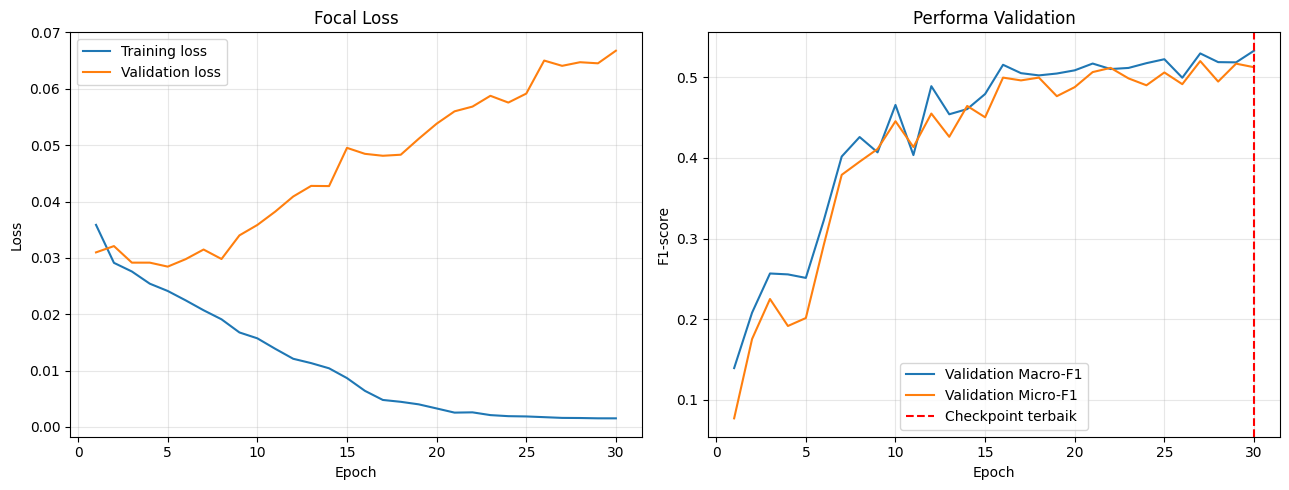

Artefak Focal Loss berhasil disimpan:

- best_focal_loss_resnet50.pt: 276330.61 KB
- best_thresholds.json: 0.63 KB
- class_distribution.csv: 0.12 KB
- focal_parameters.json: 0.03 KB
- test_metrics_per_label.csv: 0.87 KB
- test_predictions.csv: 66.41 KB
- test_summary.json: 0.38 KB
- training_curves.png: 161.43 KB
- training_history.json: 6.78 KB


In [5]:
# Menyimpan seluruh artefak Focal Loss

import matplotlib.pyplot as plt


summary_path = (
    FOCAL_OUTPUT_DIR
    / "test_summary.json"
)

per_label_path = (
    FOCAL_OUTPUT_DIR
    / "test_metrics_per_label.csv"
)

prediction_path = (
    FOCAL_OUTPUT_DIR
    / "test_predictions.csv"
)

distribution_path = (
    FOCAL_OUTPUT_DIR
    / "class_distribution.csv"
)

parameter_path = (
    FOCAL_OUTPUT_DIR
    / "focal_parameters.json"
)

curve_path = (
    FOCAL_OUTPUT_DIR
    / "training_curves.png"
)


with open(summary_path, "w") as file:
    json.dump(
        test_summary,
        file,
        indent=2
    )


per_label_table.to_csv(
    per_label_path,
    index=False
)

class_distribution_table.to_csv(
    distribution_path,
    index=False
)

with open(parameter_path, "w") as file:
    json.dump(
        {
            "alpha": FOCAL_ALPHA,
            "gamma": FOCAL_GAMMA
        },
        file,
        indent=2
    )


prediction_data = {
    "patient_id": test_patient_ids
}

for index, label_name in enumerate(LABELS):
    prediction_data[f"true_{label_name}"] = (
        test_labels[:, index].astype(int)
    )
    prediction_data[f"prob_{label_name}"] = (
        test_probabilities[:, index]
    )
    prediction_data[f"pred_{label_name}"] = (
        test_predictions[:, index].astype(int)
    )


prediction_table = pd.DataFrame(
    prediction_data
)

prediction_table.to_csv(
    prediction_path,
    index=False
)


history_table = pd.DataFrame(
    focal_history
)


figure, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)


axes[0].plot(
    history_table["epoch"],
    history_table["train_loss"],
    label="Training loss"
)

axes[0].plot(
    history_table["epoch"],
    history_table["validation_loss"],
    label="Validation loss"
)

axes[0].set_title("Focal Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)


axes[1].plot(
    history_table["epoch"],
    history_table["validation_macro_f1"],
    label="Validation Macro-F1"
)

axes[1].plot(
    history_table["epoch"],
    history_table["validation_micro_f1"],
    label="Validation Micro-F1"
)

axes[1].axvline(
    checkpoint["epoch"],
    color="red",
    linestyle="--",
    label="Checkpoint terbaik"
)

axes[1].set_title("Performa Validation")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F1-score")
axes[1].legend()
axes[1].grid(alpha=0.3)


plt.tight_layout()
plt.savefig(
    curve_path,
    dpi=200,
    bbox_inches="tight"
)
plt.show()


print("Artefak Focal Loss berhasil disimpan:\n")

for path in sorted(FOCAL_OUTPUT_DIR.iterdir()):
    print(
        f"- {path.name}: "
        f"{path.stat().st_size / 1024:.2f} KB"
    )